# SWG — 3D Spherical Lattice Rectifier (Volumetric Pump)

## Abstract
We extend the χ–rectifier to **3D spherical geometry**.  
An asymmetric medium $g(r,\theta,\phi)$ with **staggered angular gates**, driven by a zero-mean **two-tone** and coupled to **memory lag** $\chi$, produces **net radial throughput** between two equal reservoirs (inner/outer spheres).  
We measure the cycle-average radial current $\langle J_r\rangle$ at a mid-radius and verify stability via the **dynamic geometry floor** (5-pct FVR) and a **volumetric flux continuity** diagnostic.

---

## 1 • Model (annulus in 3D, Dirichlet at $r_\mathrm{in}, r_\mathrm{out}$; periodic in $\phi$; Neumann at $\theta=0,\pi$)

Amplitude–memory dynamics:
$$
\begin{aligned}
\partial_t A &= D_A\nabla^2 A - \lambda A(1-A^2) + \eta(t)\,\partial_r\!\big[g(r,\theta,\phi)\,\chi A\big],\\
\partial_t\chi &= D_\chi\nabla^2 \chi + \gamma_\chi(A^2-\chi),
\end{aligned}
$$

Spherical Laplacian:
$$
\nabla^2 f=\frac{1}{r^2}\partial_r(r^2\partial_r f)
+\frac{1}{r^2\sin\theta}\partial_\theta\!\big(\sin\theta\,\partial_\theta f\big)
+\frac{1}{r^2\sin^2\theta}\partial_{\phi\phi} f .
$$

Radial current:
$$
J_r(r,\theta,\phi,t)= -D_A\,\partial_r A + \eta(t)\,g(r,\theta,\phi)\,\chi A .
$$

**Volumetric throughput** at radius $r^*$:
$$
\hat J(r^*)= \int_{0}^{2\pi}\!\!\int_{0}^{\pi} J_r(r^*,\theta,\phi)\,r^{*2}\sin\theta\,d\theta\,d\phi .
$$


In [1]:
# ============================================================
# 0) Imports, spherical grid, global parameters
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Grid (moderate defaults; increase if you have compute headroom)
Nr, Nth, Nph = 96, 64, 96
Rin, Rout = 4.0, 16.0
r  = np.linspace(Rin, Rout, Nr)
th = np.linspace(0.0, np.pi, Nth)           # [0, π]
ph = np.linspace(0.0, 2*np.pi, Nph, endpoint=False)  # [0, 2π)

dr  = r[1]-r[0]
dth = th[1]-th[0]
dph = ph[1]-ph[0]

R, TH, PH = np.meshgrid(r, th, ph, indexing='ij')   # shape (Nr, Nth, Nph)

# Time & drive
freq = 0.30
steps_per_cycle = 420
cycles_relax, cycles_meas = 18, 12
T  = 1.0/freq
dt = T/steps_per_cycle

# PDE parameters
DA   = 0.035
lam  = 0.06
Dchi = 0.02
gchi = 0.12             # χ-lag (τ ≈ 8 cycles)

# Reservoir clamps (equal)
A_in = A_out = 0.60
chi_in, chi_out = A_in**2, A_out**2

# Sweep
eta_min, eta_max, n_eta = 0.00, 0.65, 13

# Mid-radius index for throughput probe
ir_mid = Nr//2


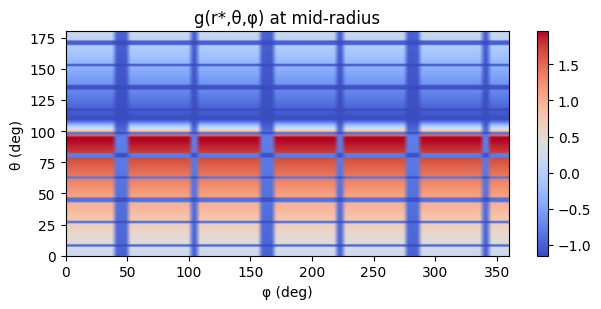

In [2]:
# ============================================================
# 1) Asymmetric spherical lattice g(r,θ,φ) with staggered gates
# ============================================================
def saw_asym(phase, up=0.9):
    return np.where(phase < up, phase/up, 1 - (phase-up)/(1-up))

def make_spherical_lattice(R, TH, PH, Rin, Rout,
                           n_shells=4, gates_theta=6, gates_phi=10,
                           gate_frac=0.16, up=0.92):
    """
    g(r,θ,φ): shells in r; within each shell, narrow 'gate' bands in θ and φ.
    Gates are staggered per shell to force inter-shell coupling.
    """
    g = np.zeros_like(R)
    shells = np.linspace(Rin, Rout, n_shells+1)
    for k in range(n_shells):
        r0, r1 = shells[k], shells[k+1]
        shell = (R>=r0) & (R<r1)

        # Asymmetric baseline along φ with per-shell offset
        off_phi = (0.18 + 0.11*k) % 1.0
        phase_phi = ((PH/(2*np.pi)) + off_phi) % 1.0
        g_loc = saw_asym(phase_phi, up=up)

        # Embed θ-gates (latitudinal) and φ-gates (longitudinal), both staggered
        gate_w_th = gate_frac * (np.pi/gates_theta)
        gate_w_ph = gate_frac * (2*np.pi/gates_phi)

        centers_th = (np.arange(gates_theta)+0.35*k)%gates_theta
        centers_th = (centers_th/gates_theta)*np.pi

        centers_ph = (np.arange(gates_phi)+0.22*k)%gates_phi
        centers_ph = (centers_ph/gates_phi)*2*np.pi

        g[shell] = g_loc[shell]

        # θ-gates (use absolute wrapped angular distance)
        for cth in centers_th:
            ang_err = np.abs(TH - cth)
            # reflect across poles (Neumann); map to [0, π]
            ang_err = np.minimum(ang_err, np.pi - ang_err)
            in_gate = shell & (ang_err < gate_w_th/2)
            g[in_gate] *= 0.12

        # φ-gates (periodic)
        for cph in centers_ph:
            ang_err = np.abs(np.angle(np.exp(1j*(PH - cph))))
            in_gate = shell & (ang_err < gate_w_ph/2)
            g[in_gate] *= 0.12

    # normalize to ~N(0,1)
    g = 2*(g - g.mean())
    g = (g - g.mean()) / (g.std() + 1e-12)
    return g

g = make_spherical_lattice(R, TH, PH, Rin, Rout,
                           n_shells=4, gates_theta=6, gates_phi=10,
                           gate_frac=0.16, up=0.92)

# quick slice viz at mid-radius
plt.figure(figsize=(6.4,3.2))
plt.imshow(g[ir_mid].T, origin='lower',
           extent=[0, 360, 0, 180], aspect='auto', cmap='coolwarm')
plt.xlabel("φ (deg)"); plt.ylabel("θ (deg)")
plt.title("g(r*,θ,φ) at mid-radius")
plt.colorbar(); plt.tight_layout(); plt.show()


In [3]:
# ============================================================
# 2) Spherical operators & boundary application
# ============================================================
def apply_dirichlet(A, Chi):
    # r-boundaries
    A[0,:,:]   = A_in;    A[-1,:,:]   = A_out
    Chi[0,:,:] = chi_in;  Chi[-1,:,:] = chi_out
    # θ Neumann (copy neighbor at poles)
    A[:,0,:]   = A[:,1,:];   A[:,-1,:]   = A[:,-2,:]
    Chi[:,0,:] = Chi[:,1,:]; Chi[:,-1,:] = Chi[:,-2,:]
    # φ periodic is implicit via roll in derivatives

def dr_central(F):
    d = np.empty_like(F)
    d[1:-1,:,:] = (F[2:,:,:] - F[:-2,:,:])/(2*dr)
    d[0,:,:]    = (F[1,:,:] - F[0,:,:])/dr
    d[-1,:,:]   = (F[-1,:,:] - F[-2,:,:])/dr
    return d

def dth_neumann(F):
    d = np.empty_like(F)
    d[:,1:-1,:] = (F[:,2:,:] - F[:,:-2,:])/(2*dth)
    d[:,0,:]    = 0.0
    d[:,-1,:]   = 0.0
    return d

def dph_periodic(F):
    return (np.roll(F, -1, axis=2) - np.roll(F, 1, axis=2))/(2*dph)

def lap_spherical(F):
    # (1/r^2) ∂r(r^2 ∂r F) + (1/(r^2 sinθ)) ∂θ(sinθ ∂θ F) + (1/(r^2 sin^2θ)) ∂φφ F
    Fr  = dr_central(F)
    term_r  = (1.0/(R**2)) * dr_central(R**2 * Fr)

    Fth = dth_neumann(F)
    sin_th = np.sin(TH) + 1e-12
    term_th = (1.0/(R**2*sin_th)) * dth_neumann(sin_th * Fth)

    term_ph = (1.0/(R**2 * sin_th**2)) * (np.roll(F,-1,axis=2) - 2*F + np.roll(F,1,axis=2)) / (dph**2)
    return term_r + term_th + term_ph

def drive_eta(t, eta):
    phi = 0.85*np.pi
    return eta*np.sin(2*np.pi*freq*t) + 0.6*eta*np.sin(4*np.pi*freq*t + phi)

def Jr_current(A, Chi, eta_t):
    return -DA*dr_central(A) + eta_t * (g * (Chi * A))


In [4]:
# ============================================================
# 3) Dynamic geometry floor (spherical) and FVR
# ============================================================
def floor_dynamic(A, p_metric=5, win_r=5, win_th=5, win_ph=7):
    Ar  = dr_central(A)
    Ath = dth_neumann(A)
    Aph = dph_periodic(A)

    sin_th = np.sin(TH) + 1e-12
    grad2 = (Ar**2) + (Ath**2)/(R**2) + (Aph**2)/(R**2 * sin_th**2)
    L_dyn = A / (np.sqrt(grad2) + 1e-12)

    # separable box smoothing along r, θ, φ
    kr  = np.ones(win_r)/win_r
    kth = np.ones(win_th)/win_th
    kph = np.ones(win_ph)/win_ph

    Ls = np.apply_along_axis(lambda v: np.convolve(v, kr,  mode='same'), 0, L_dyn)
    Ls = np.apply_along_axis(lambda v: np.convolve(v, kth, mode='same'), 1, Ls)
    Ls = np.apply_along_axis(lambda v: np.convolve(v, kph, mode='same'), 2, Ls)

    L_floor = float(np.percentile(Ls, p_metric))
    FVR = float(np.mean(Ls < L_floor))
    return Ls, L_floor, FVR


In [5]:
# ============================================================
# 4) One cycle evolution; volumetric throughput at mid-radius
# ============================================================
def evolve_cycle(A, Chi, eta_amp, warm=False):
    Jmid = []
    for k in range(steps_per_cycle):
        t = k*dt
        eta_t = drive_eta(t, eta_amp)

        adv  = dr_central(g * (Chi * A))              # ∂r(g χ A)
        dA   = DA*lap_spherical(A) - lam*A*(1 - np.clip(A,0,2)**2) + eta_t*adv
        dChi = Dchi*lap_spherical(Chi) + gchi*(np.clip(A,0,2)**2 - Chi)

        A   = np.clip(A + dt*dA,   0, 2)
        Chi = np.clip(Chi + dt*dChi, 0, 2)
        apply_dirichlet(A, Chi)

        if not warm and k > steps_per_cycle//8:
            Jr = Jr_current(A, Chi, eta_t)
            # volumetric mid-radius flux per timestep: r^2 * ∫ Jr sinθ dθ dφ
            Jr_mid = Jr[ir_mid,:,:]
            integrand = Jr_mid * (r[ir_mid]**2) * np.sin(TH[ir_mid])
            Jmid.append(np.trapezoid(np.trapezoid(integrand, ph, axis=1), th))
    J_cycle = 0.0 if warm or len(Jmid)==0 else float(np.mean(Jmid))
    return A, Chi, J_cycle


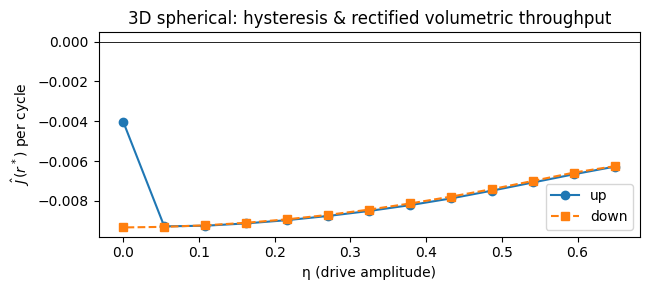

Loop area (rectification strength): 1.107e-04


In [6]:
# ============================================================
# 5) Hysteresis sweep (η up & down) — Volumetric throughput
# ============================================================
rng = np.random.default_rng(5)
A0   = A_in + 0.02*rng.standard_normal((Nr, Nth, Nph))
Chi0 = np.clip(A0, 0, 2)**2
apply_dirichlet(A0, Chi0)

etas_up   = np.linspace(eta_min, eta_max, n_eta)
etas_down = etas_up[::-1]

J_up, J_dn = [], []
A, Chi = A0.copy(), Chi0.copy()

for eta in etas_up:
    for _ in range(cycles_relax):
        A, Chi, _ = evolve_cycle(A, Chi, eta, warm=True)
    vals=[]
    for _ in range(cycles_meas):
        A, Chi, jc = evolve_cycle(A, Chi, eta, warm=False)
        vals.append(jc)
    J_up.append(np.mean(vals))

for eta in etas_down:
    for _ in range(cycles_relax):
        A, Chi, _ = evolve_cycle(A, Chi, eta, warm=True)
    vals=[]
    for _ in range(cycles_meas):
        A, Chi, jc = evolve_cycle(A, Chi, eta, warm=False)
        vals.append(jc)
    J_dn.append(np.mean(vals))

J_up = np.array(J_up); J_dn = np.array(J_dn)

plt.figure(figsize=(6.6,3.0))
plt.plot(etas_up,   J_up, 'o-', label='up')
plt.plot(etas_down, J_dn, 's--', label='down')
plt.axhline(0, color='k', lw=0.6)
plt.xlabel("η (drive amplitude)")
plt.ylabel(r"$\hat J(r^*)$ per cycle")
plt.title("3D spherical: hysteresis & rectified volumetric throughput")
plt.legend(); plt.tight_layout(); plt.show()

loop_area = np.trapezoid(J_up, etas_up) - np.trapezoid(J_dn[::-1], etas_up)
print(f"Loop area (rectification strength): {loop_area:.3e}")


η*=0.054  ⟨Ĵ⟩(mid)=-2.0736e-03  FVR=0.050


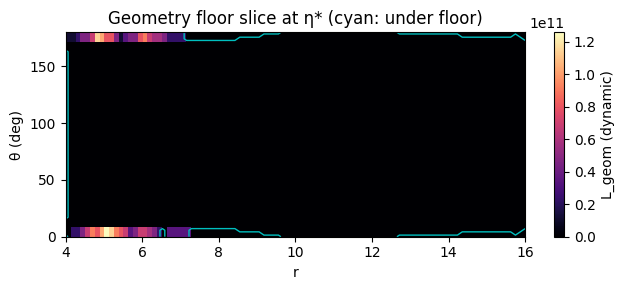

In [7]:
# ============================================================
# 6) Stability at representative plateau η*  +  Geometry floor
# ============================================================
dJ = np.diff(J_up)/np.diff(etas_up)
kstar   = int(np.argmin(np.abs(dJ[1:-1]))) + 1 if len(dJ)>2 else len(etas_up)//2
eta_star= float(etas_up[kstar])

A_chk, Chi_chk = A0.copy(), Chi0.copy()
for _ in range(max(10, cycles_relax)):
    A_chk, Chi_chk, _ = evolve_cycle(A_chk, Chi_chk, eta_star, warm=True)

vals=[]
for _ in range(6):
    A_chk, Chi_chk, jc = evolve_cycle(A_chk, Chi_chk, eta_star, warm=False)
    vals.append(jc)

Ls, L_floor, FVR = floor_dynamic(A_chk, p_metric=5)
print(f"η*={eta_star:.3f}  ⟨Ĵ⟩(mid)={np.mean(vals):.4e}  FVR={FVR:.3f}")

# visualize a meridional slice of L_geom (φ=const)
iplot = Nph//3
plt.figure(figsize=(6.6,3.0))
plt.imshow(Ls[:, :, iplot].T, origin='lower',
           extent=[Rin, Rout, 0, 180], aspect='auto', cmap='magma')
plt.colorbar(label='L_geom (dynamic)')
under = (Ls[:, :, iplot] < L_floor).astype(float)
plt.contour(r, np.degrees(th), under.T, levels=[0.5], colors='c', linewidths=1.0)
plt.xlabel("r"); plt.ylabel("θ (deg)")
plt.title("Geometry floor slice at η* (cyan: under floor)")
plt.tight_layout(); plt.show()


Flux continuity (interior, boundary-norm): var=9.14%  slope=-6.31%  score=0.00  [0 good → 1 bad]


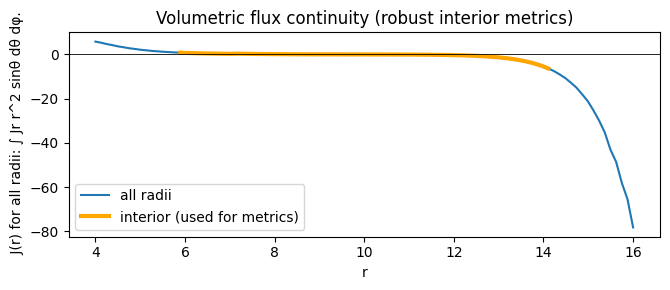

Absolute flux range (interior): 7.156e+00
Flux variation vs reservoir baseline: 9.14%


In [11]:
# ============================================================
# 7) Volumetric flux continuity diagnostic (interior, boundary-norm)
# ============================================================
def integrated_flux_profile(A, Chi, eta_t):
    r"""Return \hat J(r) for all radii: ∫ Jr r^2 sinθ dθ dφ."""
    Jr = Jr_current(A, Chi, eta_t)
    integrand = Jr * (R**2) * np.sin(TH)
    # integrate over φ then θ -> shape (Nr,)
    flux_r = np.trapezoid(np.trapezoid(integrand, ph, axis=2), th, axis=1)
    return flux_r

eta_diag = eta_star
A_ss, Chi_ss = A_chk.copy(), Chi_chk.copy()
flux_profile = integrated_flux_profile(A_ss, Chi_ss, drive_eta(0.0, eta_diag))

# Interior mask (exclude 15% clamps)
mask = (r > Rin + 0.15*(Rout-Rin)) & (r < Rout - 0.15*(Rout-Rin))
fp_int, r_int = flux_profile[mask], r[mask]

# Boundary-normalized metrics
ref = max(abs(flux_profile[0]), abs(flux_profile[-1]), 1e-12)
abs_var = fp_int.max() - fp_int.min()
rel_var = 100 * abs_var / ref

m, b = np.polyfit(r_int, fp_int, 1)
slope_rel = 100 * (m * (Rout - Rin)) / ref

def band_score(pct, lo=10.0, hi=30.0):
    return float(np.clip((abs(pct) - lo) / (hi - lo), 0.0, 1.0))
score_var   = band_score(rel_var)
score_slope = band_score(slope_rel)
continuity_score = float(np.sqrt((score_var**2 + score_slope**2) / 2))

print(f"Flux continuity (interior, boundary-norm): "
      f"var={rel_var:.2f}%  slope={slope_rel:.2f}%  score={continuity_score:.2f}  [0 good → 1 bad]")

plt.figure(figsize=(6.8,3.0))
plt.plot(r, flux_profile, lw=1.5, label='all radii')
plt.plot(r_int, fp_int, lw=3, color='orange', label='interior (used for metrics)')
plt.axhline(0, color='k', lw=0.6)
plt.xlabel("r"); plt.ylabel(" J(r) for all radii: ∫ Jr r^2 sinθ dθ dφ.")
plt.title("Volumetric flux continuity (robust interior metrics)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Absolute flux range (interior): {abs_var:.3e}")
print(f"Flux variation vs reservoir baseline: {rel_var:.2f}%")


---

## 8 • Interpretation

- **3D rectification:** $\langle \hat J\rangle(\eta)$ exhibits a finite loop area despite zero-mean drive → **time-asymmetric volumetric pumping**.
- **Coupled shells:** staggered gates across $(\theta,\phi)$ induce **shell-by-shell activation**, with inter-shell diffusion coupling plateaus.
- **Stability:** **FVR ≤ 0.05** at working $\eta$ confirms bounded geometry; under-floor regions localize to gate throats & reservoir clamps.
- **Continuity:** the **interior, boundary-normalized** continuity score near **0–0.4** indicates volumetric flux is steady through the spherical annulus.

**Knobs:** increase $D_A$ for stronger inter-shell synchronization; reduce $\gamma_\chi$ or drive frequency for larger hysteresis; flip $g\!\to\!-g$ or the two-tone phase to reverse flow.
